In [1]:
import numpy as np
import h5py as h5

from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.units as u
import astropy.constants as C

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams["figure.figsize"] = (10, 7.5)
plt.rcParams["font.size"] = 14
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["legend.frameon"] = False
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["ytick.minor.size"] = 1
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.width"] = 0.5

In [3]:
import sys, os

sys.path.append(os.path.abspath("/home/bsreedhar/models/simtools"))
from simtools.box import Snapshot, Catalogue
from simtools.sim_readers import GadgetSnapshot, GadgetCatalogue

In [4]:
from analysistools.merger_tree_tools import TreeTools

In [5]:
def read_sim_data(dir_name, 
                  particle_type,
                  snap = 122, 
                  lean_mode=True, 
                  verbose=True, 
                  load_ids=False, 
                  load_coords=True, 
                  load_vels=False,
                 ):

    snapshot_filename = dir_name + '/data/snapshot_{}.hdf5'.format('%03d' % snap)
    catalogue_filename = dir_name + '/data/fof_subhalo_tab_{}.hdf5'.format('%03d' % snap)
    read_mode = 1

    particle_type = particle_type

    cat_data = Catalogue(GadgetCatalogue,
                      {'catalogue_filename': catalogue_filename,
                       'particle_type': particle_type,
                       'verbose': verbose}
                      )
    if lean_mode:
        return cat_data
    else:
        particle_data = Snapshot(GadgetSnapshot,
                    {'snapshot_filename': snapshot_filename,
                     'particle_type': particle_type,
                     'read_mode': read_mode,
                     'load_ids':load_ids,
                     'load_coords':load_coords,
                     'load_vels':load_vels,
                     'buffer': 1.0e-7,
                     'verbose': verbose}
                    )
        return particle_data, cat_data

In [6]:
dir_name = "/home/bsreedhar/scratch/HIMALAYA/testing/diff_SNe/"

In [7]:
sim_names = ["main", "main_fth",  "diff_SNe"]
d_names = ["main", "main_fth",  "SNe"]

In [8]:
def load_data(
    dir_name, 
    particle_type,
    snap = 122,
    clean = True,
):
    
    snapshot_filename = dir_name + '/data/snapshot_{}.hdf5'.format('%03d' % snap)

    with h5.File(snapshot_filename, "r") as hf:
        
        if particle_type == 1:
            return hf["/PartType0/SNIINumSN"][()]

        if particle_type == 4:
            ProbSN = hf["/PartType4/ProbSN"][()]
            SNIIFthPref = hf["/PartType4/SNIIFthPref"][()]
            SNIIGasEnInj = hf["/PartType4/SNIIGasEnInj"][()]
                            # /PartType4/SNIIMassNgb
            SNIINumNgb = hf["/PartType4/SNIINumNgb"][()]
                            # /PartType4/SNIINumSN 

            if clean:
                # mask = ProbSN != np.inf

                mask = SNIINumNgb > 0.
                    
                ProbSN = ProbSN[mask]
                SNIIFthPref = SNIIFthPref[mask]
                SNIIGasEnInj = SNIIGasEnInj[mask]
                SNIINumNgb = SNIINumNgb[mask]

    
            return ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb

In [9]:
def compute_SFR(sim_dir, snap=35, dt_grid=10.0):

    snapfile = f"{sim_dir}/data/snapshot_{snap:03d}.hdf5"

    with h5.File(snapfile, "r") as f:

        # cosmology params
        try:
            h = f["Parameters"].attrs["HubbleParam"]
            Om0 = f["Parameters"].attrs["Omega0"]
        except KeyError:
            h = f["Header"].attrs["HubbleParam"]
            Om0 = f["Header"].attrs["Omega0"]

        header = f["Header"].attrs
        a_now = header["Time"]

        a_form = f["PartType4/StellarFormationTime"][:]
        mstar = f["PartType4/InitialStellarMass"][:] * 1e10 / h
        net_mstar = f["PartType4/Masses"][:] * 1e10 / h

    cosmo = FlatLambdaCDM(H0=100*h, Om0=Om0)

    t_now = cosmo.age(1/a_now - 1).to(u.Myr).value
    t_form = cosmo.age(1/a_form - 1).to(u.Myr).value

    # clean
    mask = np.isfinite(t_form)
    t_form = t_form[mask]
    mstar = mstar[mask]

    # -------------------------
    # TIME GRID (no smoothing)
    # -------------------------
    t_min = 0.0
    t_max = t_now

    edges = np.arange(t_min, t_max + dt_grid, dt_grid)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # -------------------------
    # HISTOGRAM SFH
    # -------------------------
    sfr, _ = np.histogram(
        t_form,
        bins=edges,
        weights=mstar
    )

    sfr = sfr / (dt_grid * 1e6)  # Msun/yr
    redshifts = z_at_value(cosmo.age, centers*u.Myr)
    
    return centers, redshifts, sfr, net_mstar.sum()

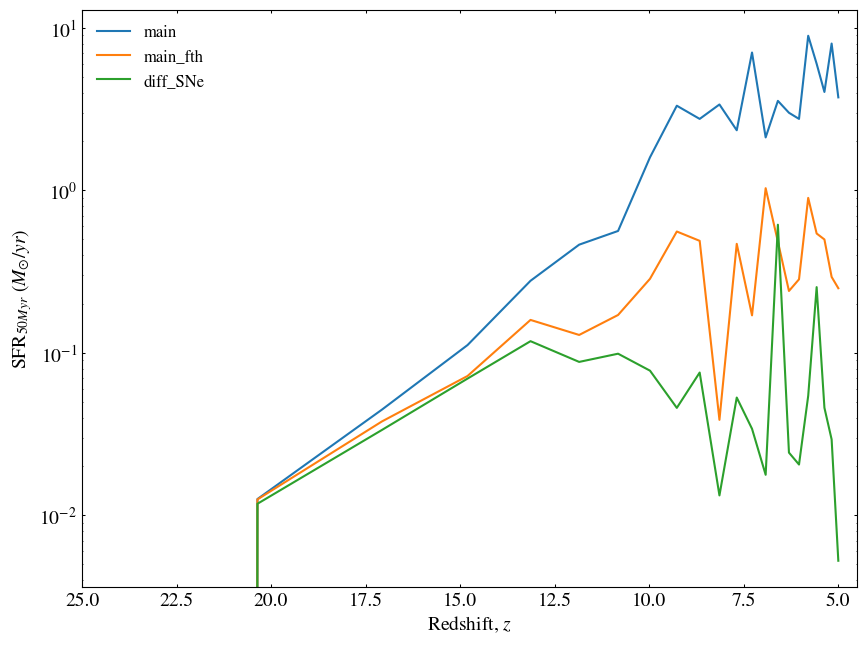

In [10]:
fig, axes = plt.subplots()


for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    
    centers, redshifts, sfr, net_mstar = compute_SFR(dir_name + sim_name, snap=35, dt_grid = 50)

    # axes.plot(centers, sfr/net_mstar, label=sim_name + kind, ls=ls)
    axes.plot(redshifts, sfr, label=sim_name)

axes.set_yscale("log")

axes.set_ylabel(r"SFR$_{50 Myr}$ $(M_{\odot}/yr)$")

# axes.set_xlabel("Time (Myr)")
axes.set_xlabel(r"Redshift, $z$")

axes.set_xlim(25,4.5)
axes.legend(loc="best")

# plt.savefig("./plots/SFR_HM2012.pdf", dpi=300)

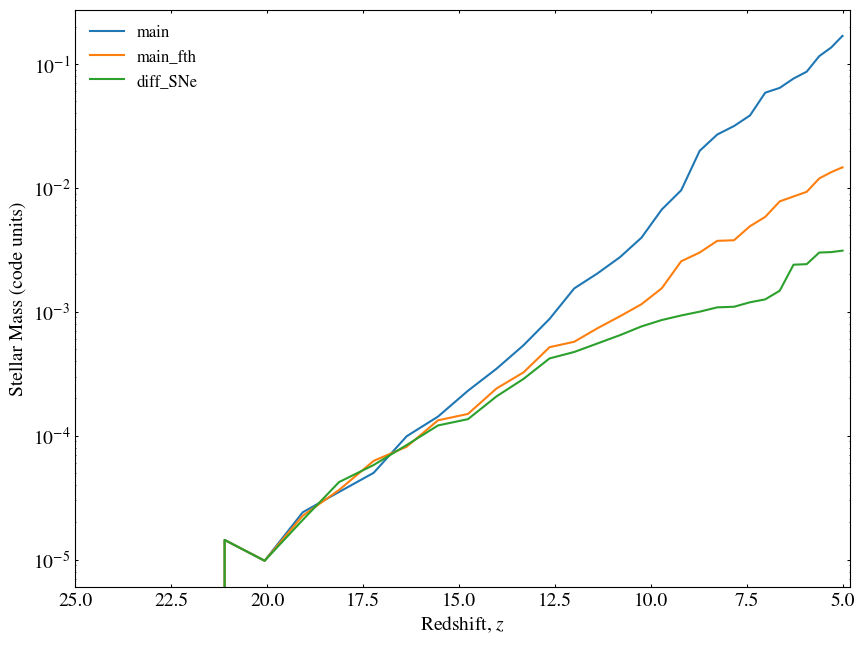

In [11]:
snaps = np.arange(0, 36)

fig, ax = plt.subplots()

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    
    s_mass = []
    redshifts = []
    for snap in snaps:
        with h5.File(sim_dir + f"/data/snapshot_{snap:03d}.hdf5", "r") as hf:
            redshifts.append(hf["Header"].attrs["Redshift"])
            try:
                s_mass.append(np.sum(hf["PartType4"]["Masses"][()]))
            except(KeyError):
                s_mass.append(0)

    # print(nstars)
    ax.plot(redshifts, s_mass, label=sim_name)
    
    ax.set_yscale("log")
    ax.invert_xaxis()
    
    ax.set_ylabel("Stellar Mass (code units)")
    ax.set_xlabel(r"Redshift, $z$")
    ax.legend(loc="best")

    ax.set_xlim(25, 4.8)

### For each gas particle we ask how many times it has been heated by SNe in its lifetime.

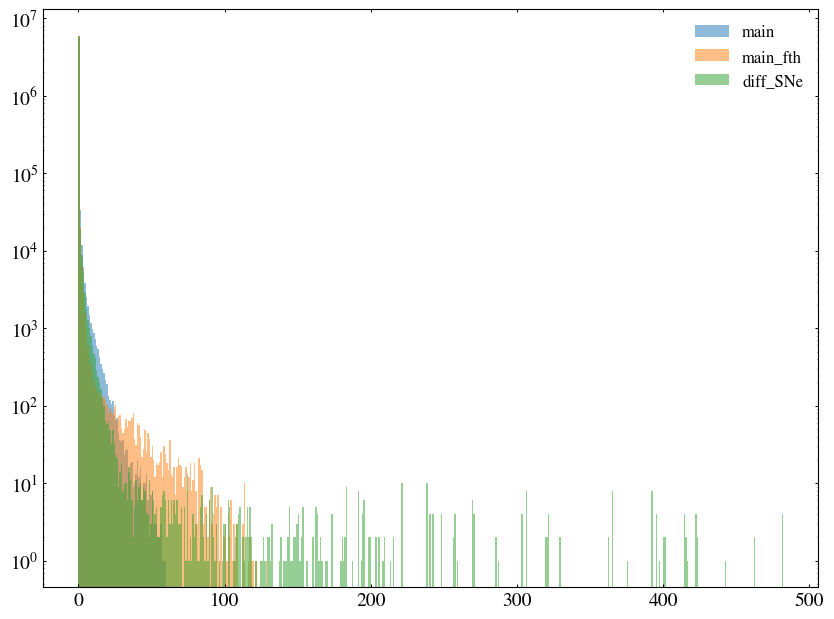

In [12]:
fig, ax = plt.subplots()

all_hits = []

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    NumHits = load_data(sim_dir, 1, 35)
    all_hits.append(NumHits)

bin_width = 1
max_hits = max(np.max(x) for x in all_hits)

bins = np.arange(0, max_hits + bin_width, bin_width)

for sim_name, NumHits in zip(sim_names, all_hits):
    ax.hist(NumHits, bins=bins, alpha=0.5, label=sim_name)

# ax.set_xscale("symlog", linthresh=10)
ax.set_yscale("log")

ax.legend()

### This is obviously skewed towards zero as most of them are never hit by SNe. But we see that the distribution extends to high (~500) values. Below we look at what is the highest NumHit as well as how many GasP have more than 100 hits.

In [13]:
for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    NumHits = load_data(sim_dir, 1, 35)
    print(f"For {sim_name}, max NumHits is ", NumHits.max())
    print(f"and number of GasP with >100 is {(NumHits>100).sum()}\n")

For main, max NumHits is  59.0
and number of GasP with >100 is 0

For main_fth, max NumHits is  128.0
and number of GasP with >100 is 41

For diff_SNe, max NumHits is  482.0
and number of GasP with >100 is 286



### Now let's look at the expected vs realised probability of hits. 
I use $\dfrac{\mathrm{Hit}}{\mathrm{Ngb}} - \mathrm{Prob}$ for this. This takes, for each StarP, the actual number of gas particles it heated (hit) out of max possible (Ngb) and the theoretically calculated probability (Prob). We expect this to be centered around zero.

Text(0.05, 0.95, '$\\dfrac{\\mathrm{Hit}}{\\mathrm{Ngb}} - \\mathrm{Prob}$')

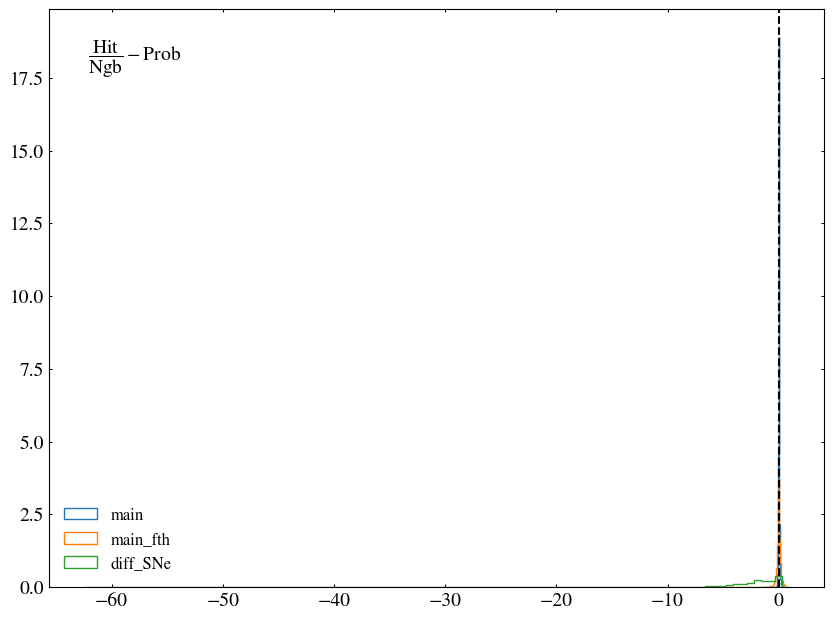

In [14]:
fig, ax = plt.subplots()

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(sim_dir, 4, 35)

    diff = SNIIGasEnInj / SNIINumNgb - ProbSN

    ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

ax.axvline(0, ls="--", color="black")

# ax.set_xscale("symlog", linthresh=1e-6)
ax.legend()

text = r"$\dfrac{\mathrm{Hit}}{\mathrm{Ngb}} - \mathrm{Prob}$"

ax.text(
    0.05, 0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

# ax.set_xlim(-2, 2),

### But there can be stars (esp PopIII SNe) for which the probablility can be orders of magnitude higher than 1. So for these I reset the probability to 1 and recompute:

Text(0.05, 0.95, '$\\dfrac{\\mathrm{Hit}}{\\mathrm{Ngb}} - \\mathrm{Prob}$')

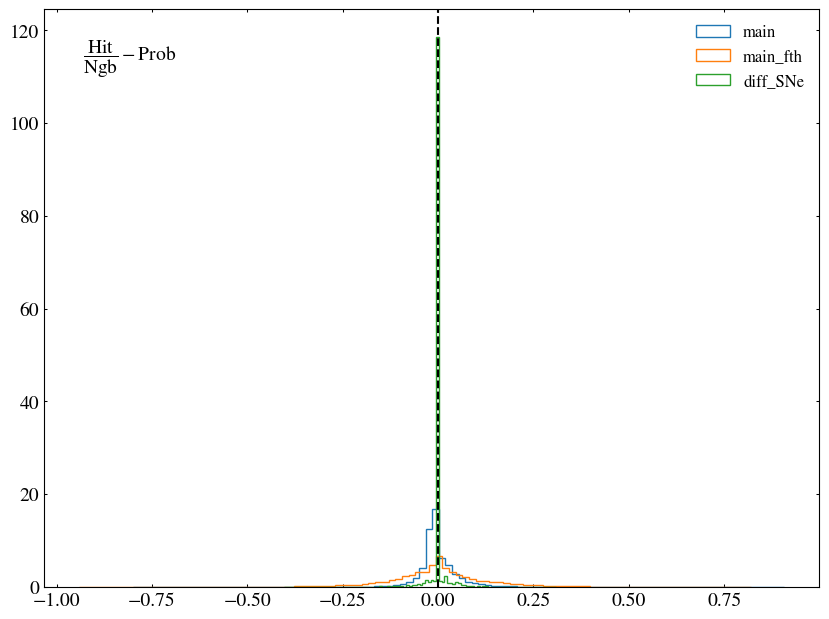

In [15]:
fig, ax = plt.subplots()

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(sim_dir, 4, 35)

    ProbSN[ProbSN > 1] = 1

    diff = SNIIGasEnInj / SNIINumNgb - ProbSN

    ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

ax.axvline(0, ls="--", color="black")

# ax.set_xscale("symlog", linthresh=1e-6)
ax.legend()

text = r"$\dfrac{\mathrm{Hit}}{\mathrm{Ngb}} - \mathrm{Prob}$"

ax.text(
    0.05, 0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

# ax.set_xlim(-2, 2),

(-2.0, 2.0)

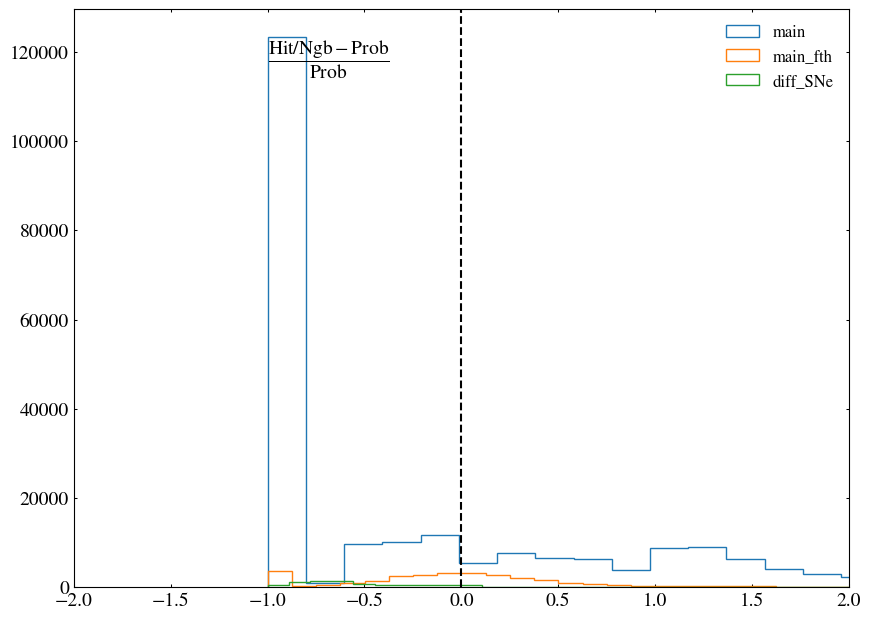

In [16]:
fig, ax = plt.subplots()

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(sim_dir, 4, 35)
    
    diff = (SNIIGasEnInj / SNIINumNgb - ProbSN) / ProbSN
    
    ax.hist(diff, bins=100, histtype="step", label=sim_name,)

ax.axvline(0, ls="--", color="black")

# ax.set_xscale("symlog", linthresh=1e-6)
ax.legend()

text = r"$\dfrac{\mathrm{Hit}/\mathrm{Ngb} - \mathrm{Prob}}{\mathrm{Prob}}$"

ax.text(
    0.25, 0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)
ax.set_xlim(-2, 2)

(-2.0, 2.0)

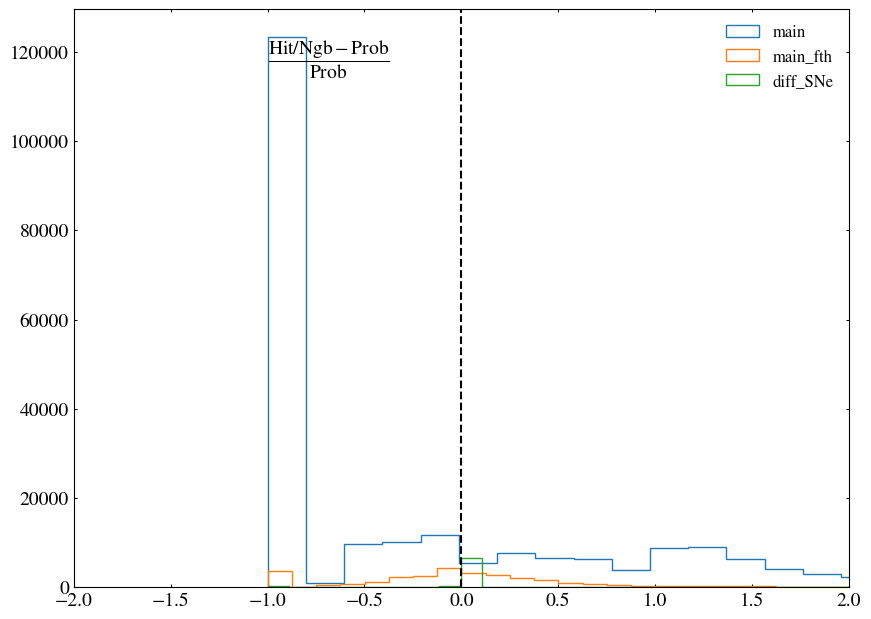

In [17]:
fig, ax = plt.subplots()

for sim_name in sim_names:
    sim_dir = dir_name + sim_name
    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(sim_dir, 4, 35)

    ProbSN[ProbSN > 1] = 1

    diff = (SNIIGasEnInj / SNIINumNgb - ProbSN) / ProbSN
    
    ax.hist(diff, bins=100, histtype="step", label=sim_name,)

ax.axvline(0, ls="--", color="black")

# ax.set_xscale("symlog", linthresh=1e-6)
ax.legend()

text = r"$\dfrac{\mathrm{Hit}/\mathrm{Ngb} - \mathrm{Prob}}{\mathrm{Prob}}$"

ax.text(
    0.25, 0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)
ax.set_xlim(-2, 2)

### HIMALAYA_TABLES: StarID 2798474 Z=0.00198882603520195 >= thresh=2.0004642e-06 -> PopII StarP.

In [18]:
with h5.File(dir_name + "diff_SNe/data/snapshot_035.hdf5", "r") as hf:
    IDs = hf["PartType4/ParticleIDs"][()]
    Z_tot = hf["PartType4/Metallicity"][()][:, 0]

In [19]:
indx = IDs == 2798474

In [20]:
Z_tot[indx]

array([0.00198883])

In [21]:
THRESH = 2.0004642e-06

In [22]:
def load_data_alt(
    dir_name, 
    snap,
    kind
):
    
    snapshot_filename = dir_name + '/data/snapshot_{}.hdf5'.format('%03d' % snap)

    with h5.File(snapshot_filename, "r") as hf:

        Z_tot = hf["PartType4/Metallicity"][()][:, 0]
        
        ProbSN = hf["/PartType4/ProbSN"][()]
        SNIIFthPref = hf["/PartType4/SNIIFthPref"][()]
        SNIIGasEnInj = hf["/PartType4/SNIIGasEnInj"][()]
                        # /PartType4/SNIIMassNgb
        SNIINumNgb = hf["/PartType4/SNIINumNgb"][()]
                        # /PartType4/SNIINumSN 
        

    # mask = ProbSN != np.inf
    mask = SNIINumNgb > 0.
    
    Z_tot = Z_tot[mask]
    ProbSN = ProbSN[mask]
    SNIIFthPref = SNIIFthPref[mask]
    SNIIGasEnInj = SNIIGasEnInj[mask]
    SNIINumNgb = SNIINumNgb[mask]

    
    if kind == "PopII":
        indx = Z_tot >= THRESH
    
    if kind == "PopIII":
        indx = Z_tot < THRESH
    
    return ProbSN[indx], SNIIFthPref[indx], SNIIGasEnInj[indx], SNIINumNgb[indx]

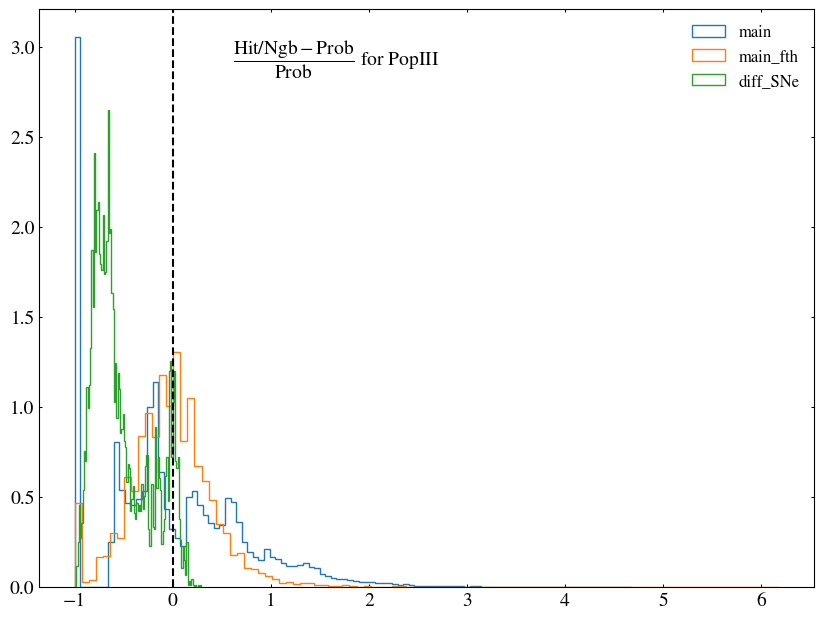

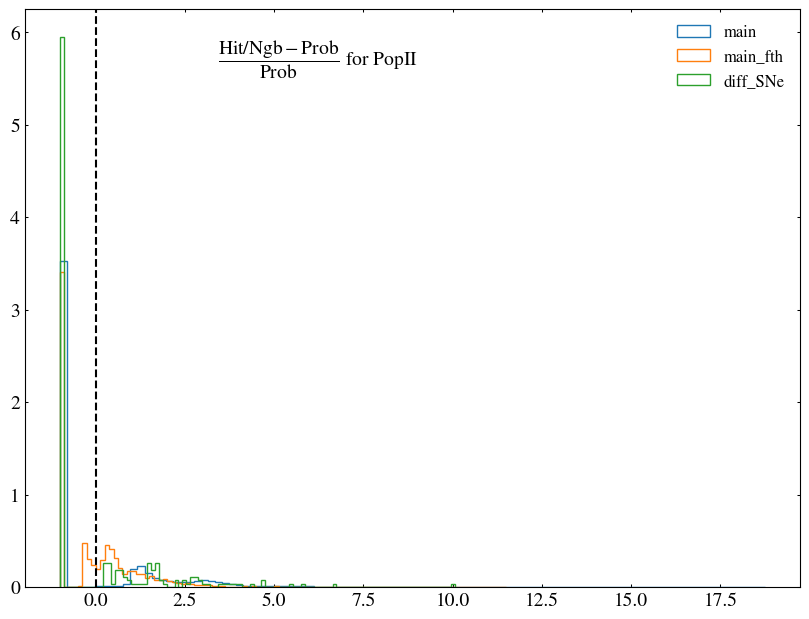

In [23]:
for kind in ["PopIII", "PopII"]:

    fig, ax = plt.subplots()
    
    for sim_name in sim_names:
        sim_dir = dir_name + sim_name
        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(sim_dir, snap = 35, kind=kind)
    
        diff = (SNIIGasEnInj / SNIINumNgb - ProbSN) / ProbSN
        
        ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

    ax.axvline(0, ls="--", color="black")
    
    # ax.set_xscale("symlog", linthresh=1e-6)
    ax.legend()
    
    text = rf"$\dfrac{{\mathrm{{Hit}}/\mathrm{{Ngb}} - \mathrm{{Prob}}}}{{\mathrm{{Prob}}}}$ for {kind}"    
    ax.text(
        0.25, 0.95,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    plt.show()


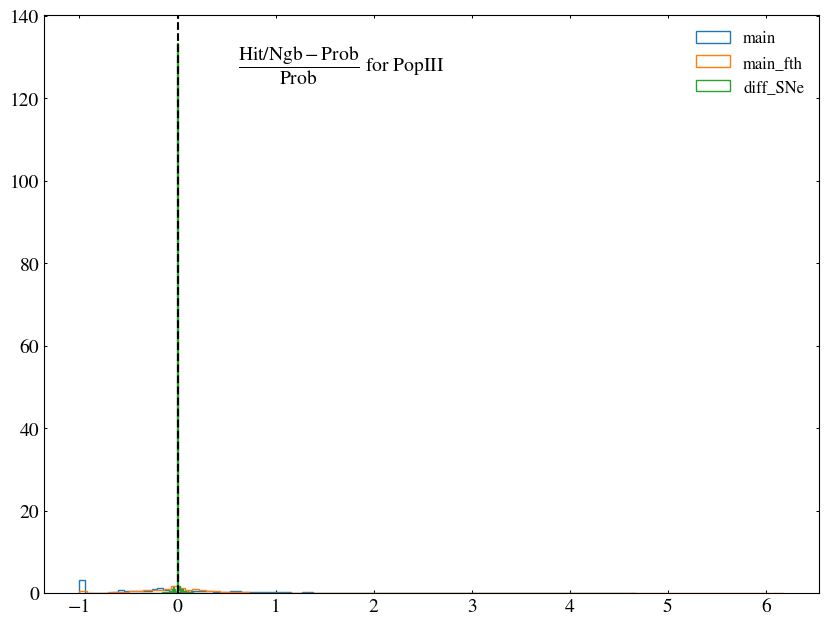

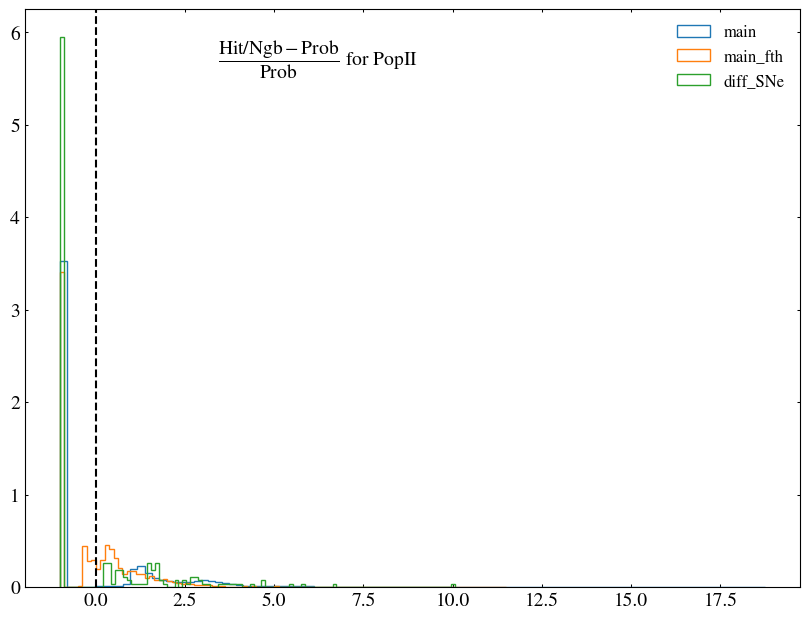

In [24]:
for kind in ["PopIII", "PopII"]:

    fig, ax = plt.subplots()
    
    for sim_name in sim_names:
        sim_dir = dir_name + sim_name
        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(sim_dir, snap = 35, kind=kind)

        ProbSN[ProbSN > 1] = 1

        diff = (SNIIGasEnInj / SNIINumNgb - ProbSN) / ProbSN
        
        ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

    ax.axvline(0, ls="--", color="black")
    
    # ax.set_xscale("symlog", linthresh=1e-6)
    ax.legend()
    
    text = rf"$\dfrac{{\mathrm{{Hit}}/\mathrm{{Ngb}} - \mathrm{{Prob}}}}{{\mathrm{{Prob}}}}$ for {kind}"    
    ax.text(
        0.25, 0.95,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    plt.show()


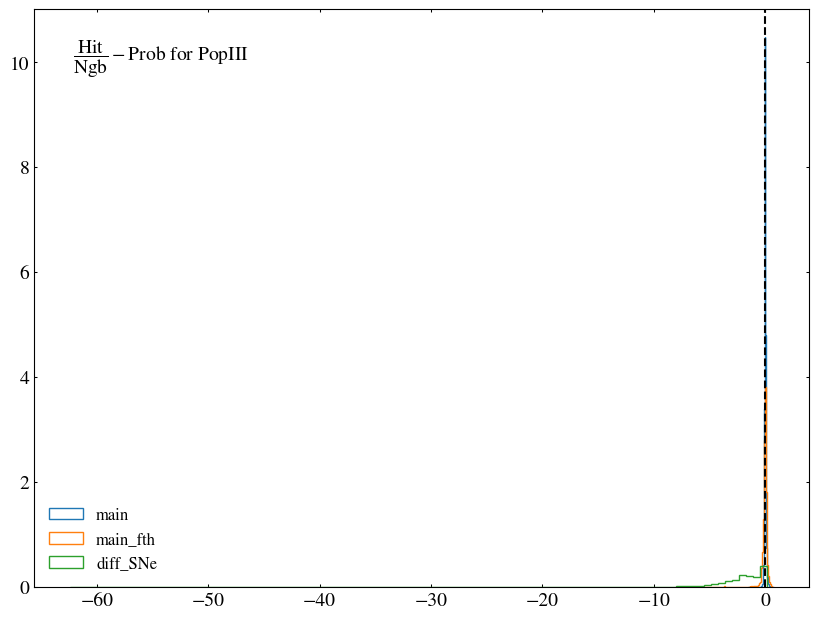

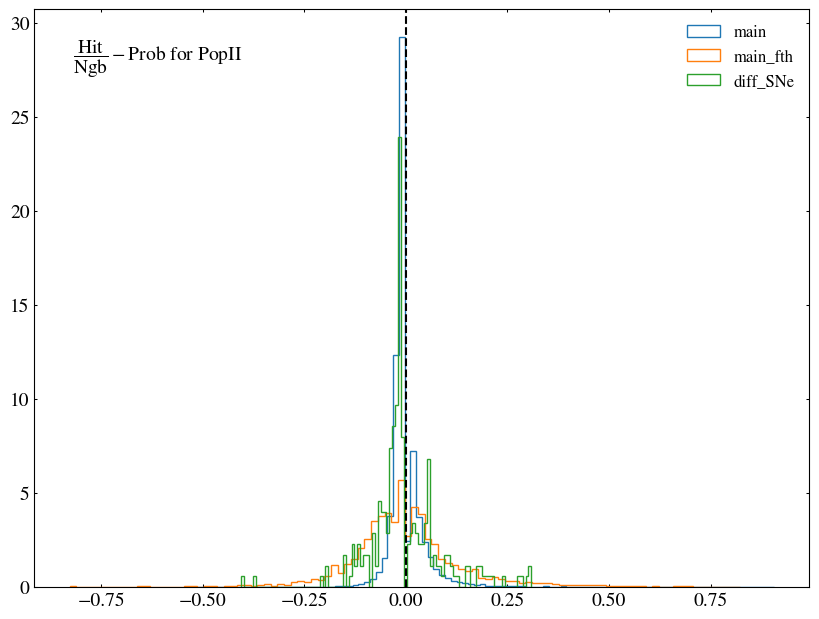

In [25]:
for kind in ["PopIII", "PopII"]:
    
    fig, ax = plt.subplots()
    
    for sim_name in sim_names:
        sim_dir = dir_name + sim_name
        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(sim_dir, snap = 35, kind=kind)
    
        diff = (SNIIGasEnInj / SNIINumNgb - ProbSN)
        
        ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

    ax.axvline(0, ls="--", color="black")
    # ax.set_xscale("symlog", linthresh=1e-6)
    ax.legend()

    text = rf"$\dfrac{{\mathrm{{Hit}}}}{{\mathrm{{Ngb}}}} - \mathrm{{Prob}}$ for {kind}"

    ax.text(
        0.05, 0.95,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    plt.show()

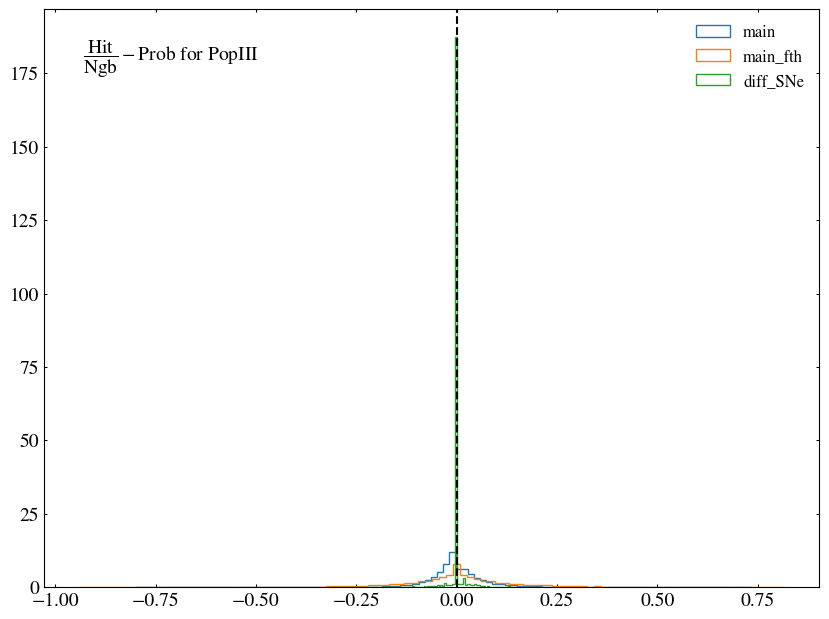

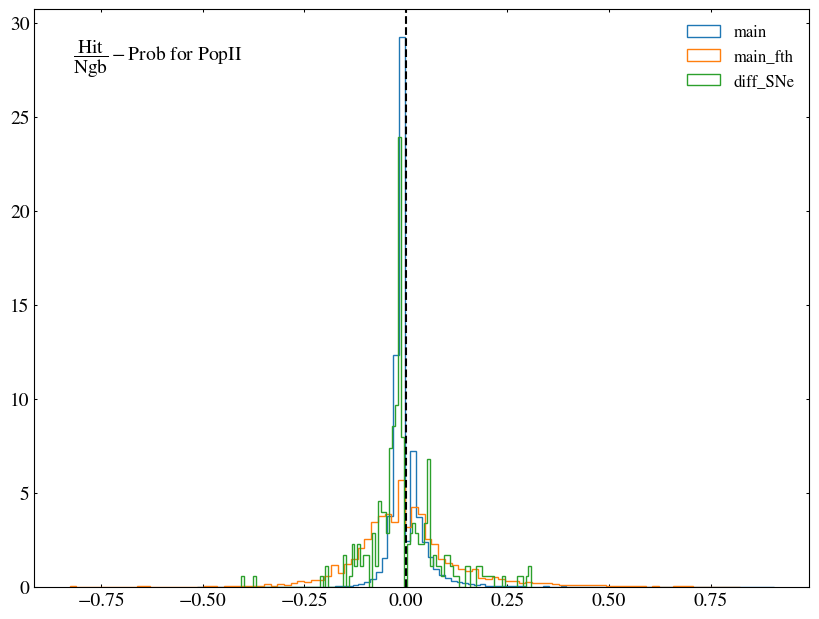

In [26]:
for kind in ["PopIII", "PopII"]:
    
    fig, ax = plt.subplots()
    
    for sim_name in sim_names:
        sim_dir = dir_name + sim_name
        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(sim_dir, snap = 35, kind=kind)

        ProbSN[ProbSN > 1] = 1

        diff = (SNIIGasEnInj / SNIINumNgb - ProbSN)
        
        ax.hist(diff, bins=100, histtype="step", label=sim_name, density=True)

    ax.axvline(0, ls="--", color="black")
    # ax.set_xscale("symlog", linthresh=1e-6)
    ax.legend()

    text = rf"$\dfrac{{\mathrm{{Hit}}}}{{\mathrm{{Ngb}}}} - \mathrm{{Prob}}$ for {kind}"

    ax.text(
        0.05, 0.95,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    plt.show()

In [27]:
id_ = 1968458

for sim_name in sim_names:
    with h5.File(dir_name + f"{sim_name}/data/snapshot_035.hdf5", "r") as hf:
    
        IDs = hf["/PartType4/ParticleIDs"][()]
        ProbSN = hf["/PartType4/ProbSN"][()]
        SNIIFthPref = hf["/PartType4/SNIIFthPref"][()]
        SNIIGasEnInj = hf["/PartType4/SNIIGasEnInj"][()]
                        # /PartType4/SNIIMassNgb
        SNIINumNgb = hf["/PartType4/SNIINumNgb"][()]
                        # /PartType4/SNIINumSN 
        
        indx = IDs == id_

        print(f"For {sim_name}:\n Theoretical Prob: {ProbSN[indx]}, Fth: {SNIIFthPref[indx]}, hit: {SNIIGasEnInj[indx]}, out of {SNIINumNgb[indx]} Ngb; Real prob:{SNIIGasEnInj[indx]/SNIINumNgb[indx]}")

For main:
 Theoretical Prob: [0.02215048], Fth: [1.], hit: [1.], out of [117.] Ngb; Real prob:[0.00854701]
For main_fth:
 Theoretical Prob: [0.06645145], Fth: [2.99999995], hit: [5.], out of [117.] Ngb; Real prob:[0.04273504]
For diff_SNe:
 Theoretical Prob: [0.54239487], Fth: [1.], hit: [62.], out of [117.] Ngb; Real prob:[0.52991453]


### Compute how many more we could have heated...

$N_{exp} = Prob * N_{ngb}$

So, $N_{extra} = Prob*N_{ngb} - N_{hit}$

In [28]:
for sim_name in sim_names:
    print(f"For {sim_name}")

    for kind in ["PopIII", "PopII"]:

        sim_dir = dir_name + sim_name
        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(
            sim_dir, snap=35, kind=kind
        )

        print(
            f"For {kind} we hit {SNIIGasEnInj.sum()} "
            f"out of max possible {SNIINumNgb.sum()}"
        )

        mask = ProbSN > 1

        actual_frac = SNIIGasEnInj[mask] / SNIINumNgb[mask]

        # waste = (ProbSN[mask] - actual_frac) / ProbSN[mask]

        could_have_heated = (
            ProbSN[mask] * SNIINumNgb[mask]
            - SNIIGasEnInj[mask]
        ).sum()

        print(f"could have heated {could_have_heated} more GasP")

    print()

For main
For PopIII we hit 148179.0 out of max possible 2657113.0
could have heated 13.026376784394984 more GasP
For PopII we hit 56724.0 out of max possible 4389240.0
could have heated 0.0 more GasP

For main_fth
For PopIII we hit 102866.0 out of max possible 485777.0
could have heated 1967.361616589562 more GasP
For PopII we hit 5853.0 out of max possible 93192.0
could have heated 17.283094905564827 more GasP

For diff_SNe
For PopIII we hit 153077.0 out of max possible 179677.0
could have heated 166772.45353961975 more GasP
For PopII we hit 117.0 out of max possible 3842.0
could have heated 0.0 more GasP



In [29]:
for sim_name in sim_names:
    
    sim_dir = dir_name + sim_name
    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(sim_dir, 4, 35, clean = False) 

    mask = SNIINumNgb == 0
    
    print(f"{sim_name} had {mask.sum()} stars with no Ngb!!!")


    assert (SNIIGasEnInj[mask] == 0.).all()
    assert (SNIINumNgb[mask] == 0.).all()    

main had 1188 stars with no Ngb!!!
main_fth had 439 stars with no Ngb!!!
diff_SNe had 20 stars with no Ngb!!!


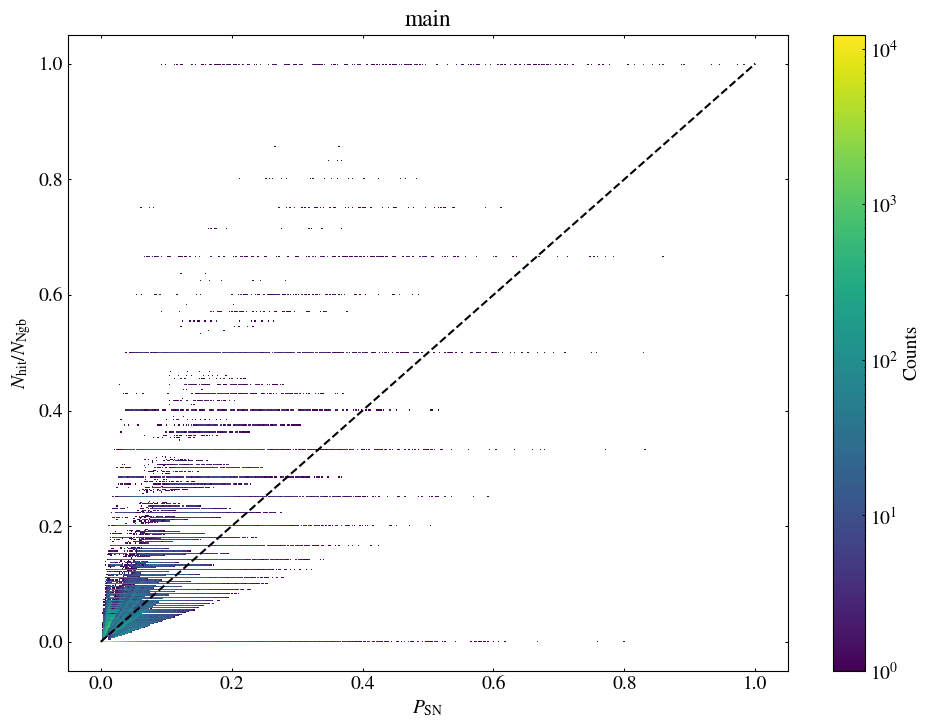

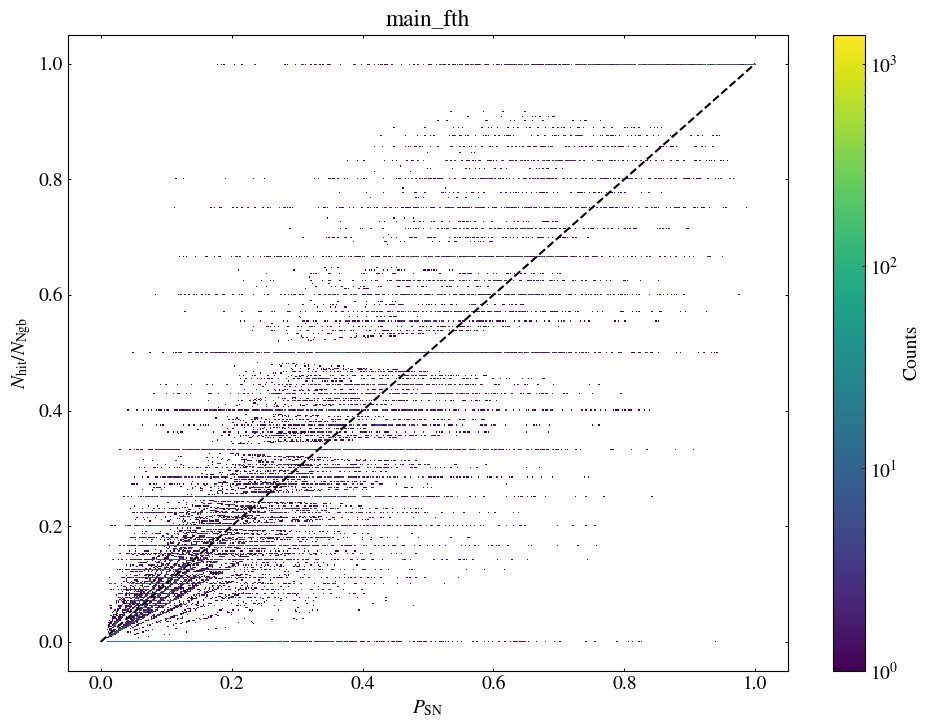

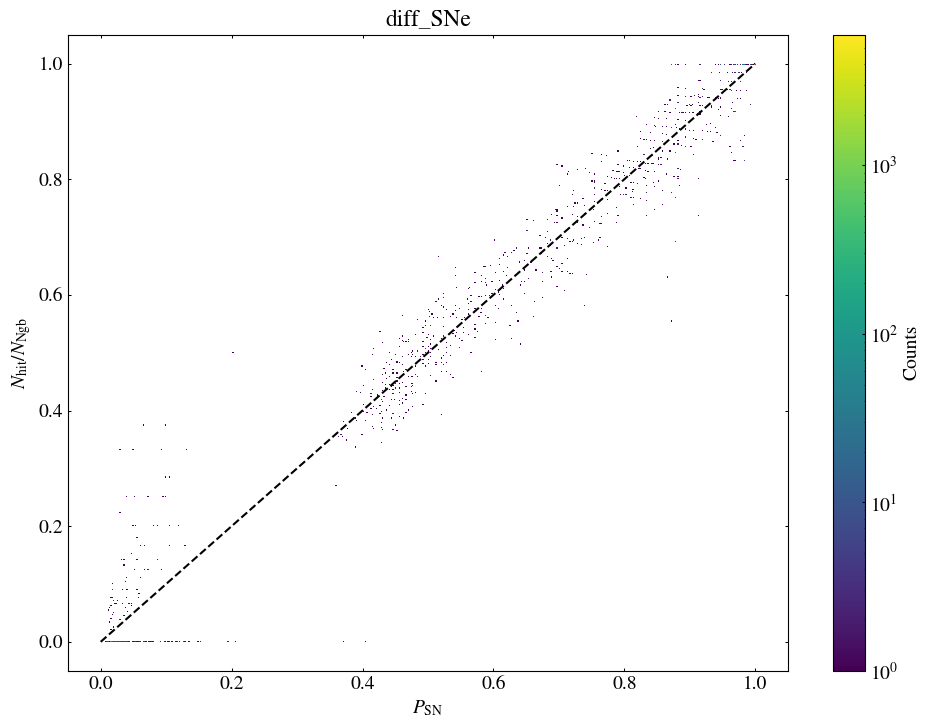

In [30]:
from matplotlib.colors import LogNorm

for sim_name in sim_names:

    fig, ax = plt.subplots()
    sim_dir = dir_name + sim_name

    ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data(
        sim_dir,
        4,
        35,
        clean=True
    )

    ProbSN[ProbSN > 1] = 1

    hit_fraction = SNIIGasEnInj / SNIINumNgb

    h = ax.hist2d(
        ProbSN,
        hit_fraction,
        bins=500,
        norm=LogNorm()
    )

    fig.colorbar(
        h[3],
        ax=ax,
        label="Counts"
    )

    ax.set_ylabel(r"$N_{\rm hit}/N_{\rm Ngb}$")
    ax.set_xlabel(r"$P_{\rm SN}$")
    ax.set_title(f"{sim_name}")

    # Expected relation
    ax.plot(
        [0, 1],
        [0, 1],
        ls="--",
        color="black")

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

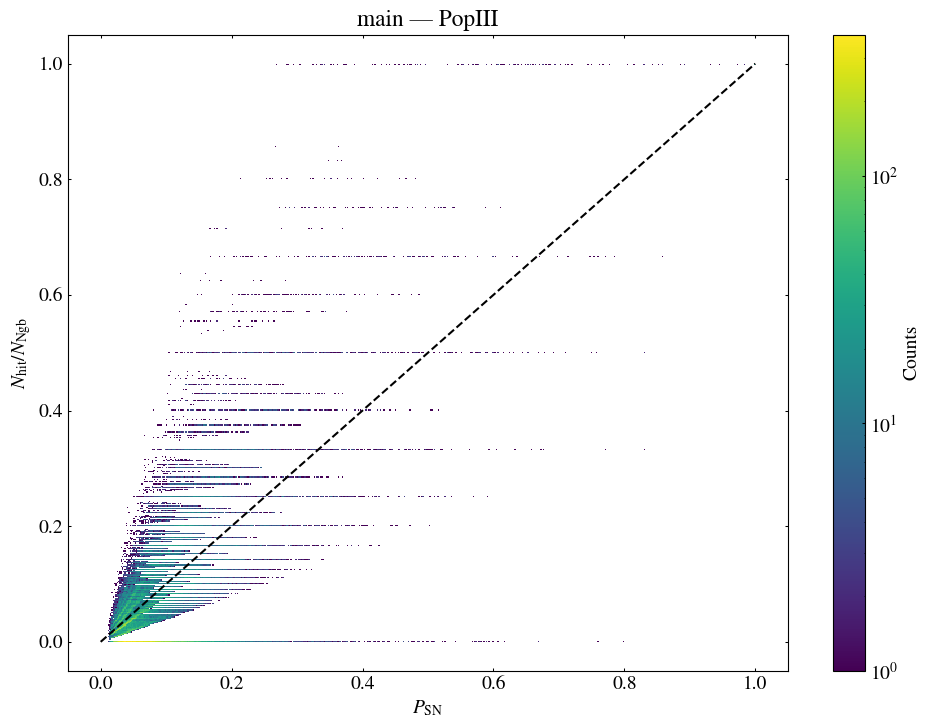

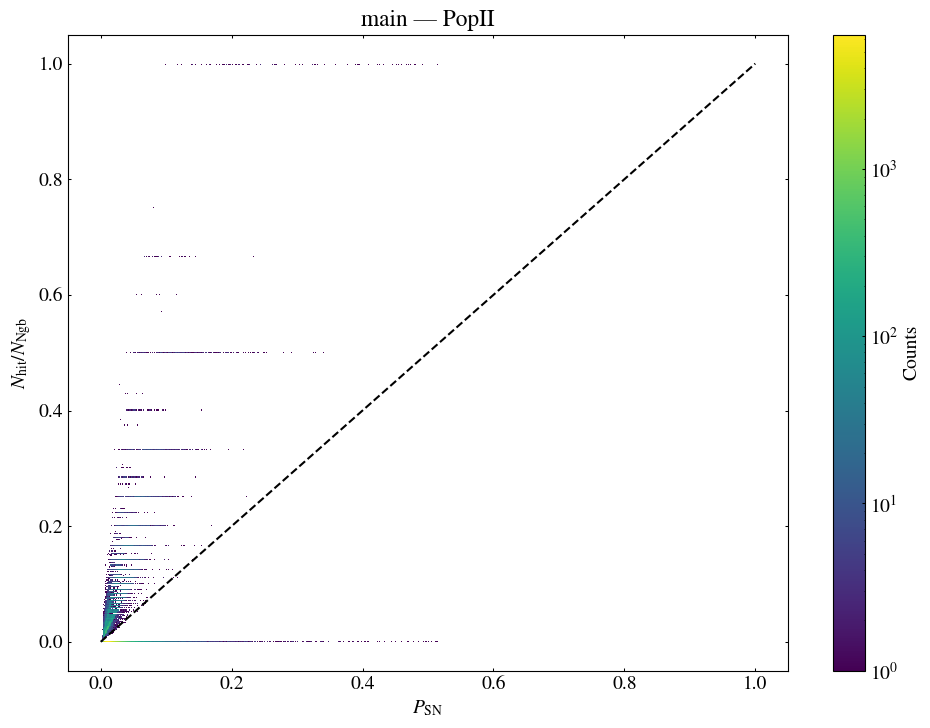

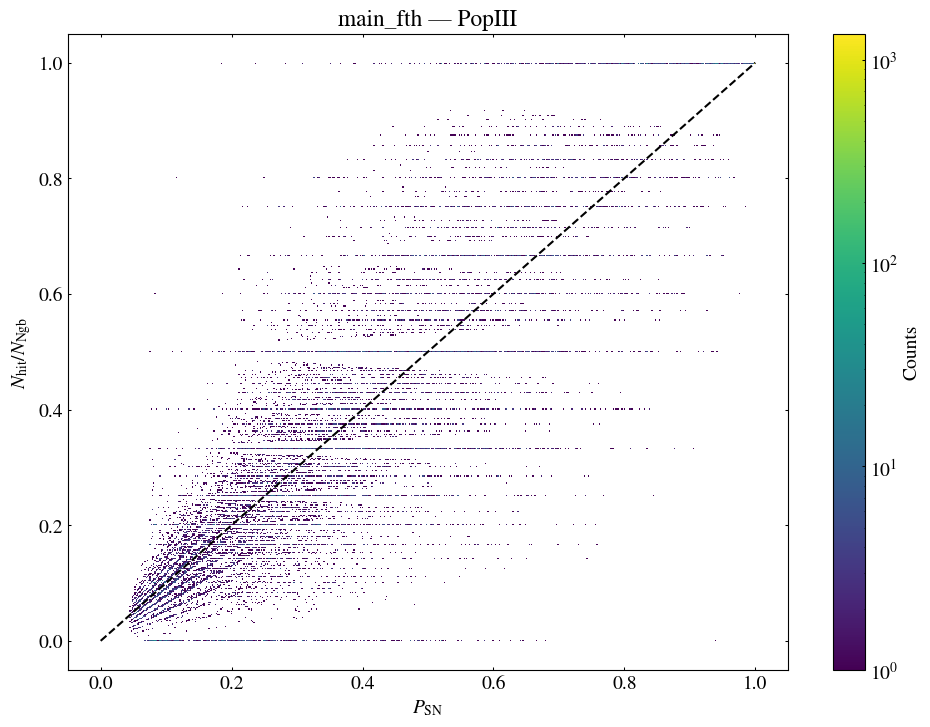

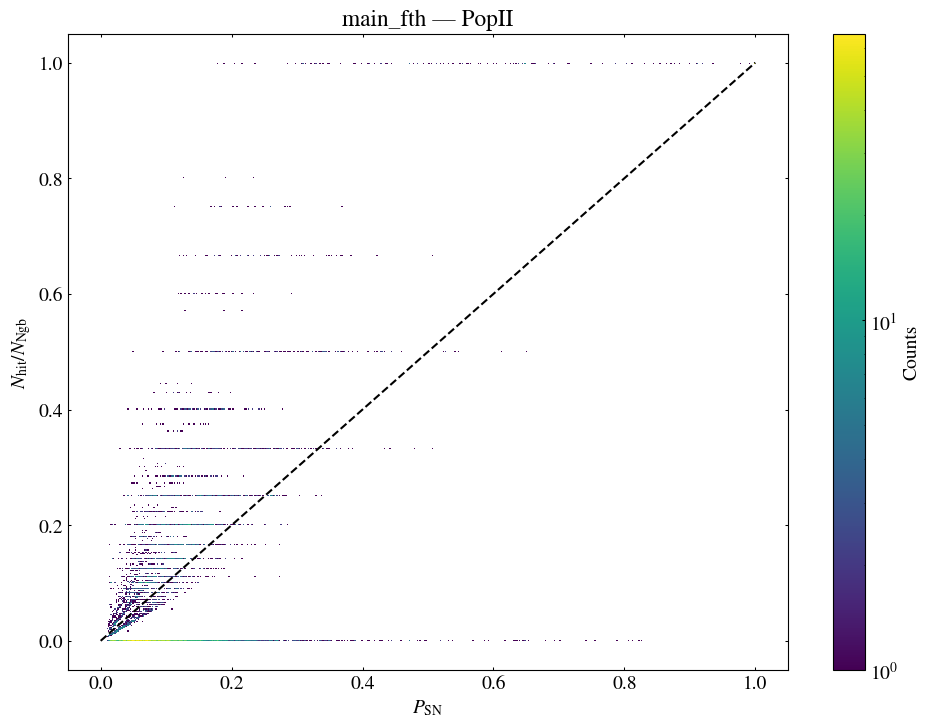

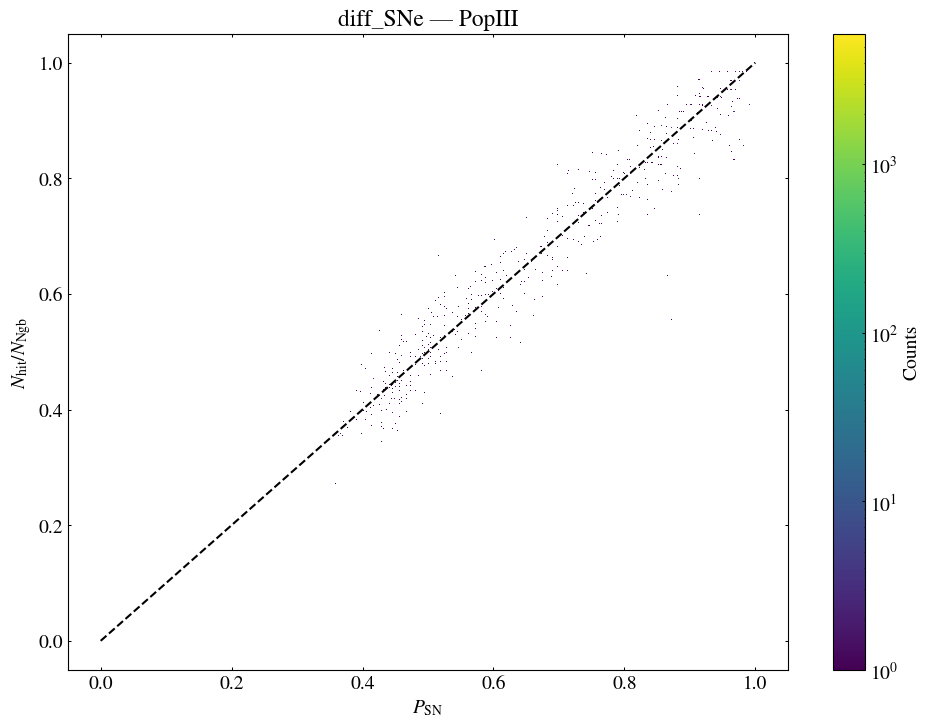

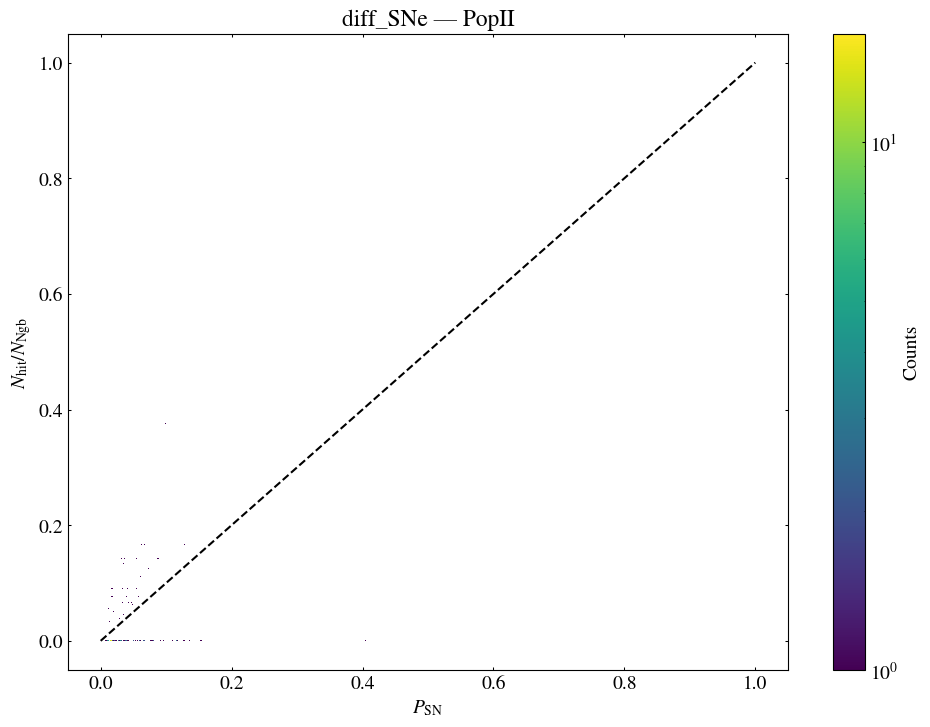

In [31]:
from matplotlib.colors import LogNorm

for sim_name in sim_names:
    for kind in ["PopIII", "PopII"]:

        fig, ax = plt.subplots()
        sim_dir = dir_name + sim_name

        ProbSN, SNIIFthPref, SNIIGasEnInj, SNIINumNgb = load_data_alt(
            sim_dir,
            35,
            kind=kind,
        )

        ProbSN[ProbSN > 1] = 1

        hit_fraction = SNIIGasEnInj / SNIINumNgb

        h = ax.hist2d(
            ProbSN,
            hit_fraction,
            bins=500,
            norm=LogNorm()
        )

        fig.colorbar(
            h[3],
            ax=ax,
            label="Counts"
        )

        ax.set_ylabel(r"$N_{\rm hit}/N_{\rm Ngb}$")
        ax.set_xlabel(r"$P_{\rm SN}$")
        ax.set_title(f"{sim_name} — {kind}")

        # Expected relation
        ax.plot(
            [0, 1],
            [0, 1],
            ls="--",
            color="black")

        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        plt.tight_layout()
        plt.show()